In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import signal
import pandas as pd
from tqdm.autonotebook import tqdm

C:\Users\shiva\AppData\Local\Temp\ipykernel_26028\197246.py:5: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## HH Model

In [10]:
class HHModel():
    def __init__(self, dt = 0.01, gK_max=36.0, gNa_max=120.0): # accepts gK and gNa as args
        # --- Standard HH Parameters ---
        self.gK_max = gK_max       # mS/cm^2, milliSiemens per square centimeter (mS/cm²)
        self.gNa_max = gNa_max     # mS/cm^2
        self.gl = 0.3              # mS/cm^2
        self.E_Na = 50             # mV
        self.E_K = -77             # mV
        self.E_l = -54.387         # mV
        self.C = 1.0               # uF/cm^2
        # -----------------------------
        self.dt = dt

    def model(self, I_app: float, T: float):
        '''
        I_app : Applied current in microAmperes per square centimeter (µA/cm²)
        T     : Total time to simulate in milliseconds (ms)
        Returns: time vector, voltage vector, gating variables m, n, h, and conductances gNa, gK
        '''
        v_monitor = []
        m_monitor = []
        n_monitor = []
        h_monitor = []
        gNa_monitor, gK_monitor = [], [] # Add monitors for conductance    

        v = -64.9964 # mv
        # refractory period is an emergent property of the model, not an explicit parameter
        # appears to be 77 ms for gK_max = 36.0, gNa_max = 120.0
        # start the simulation at steady state values of gating variables
        m = 0.0530
        h = 0.5960
        n = 0.3177
        time = np.arange(0, T, self.dt)

        for i in range(len(time)):
            gNa = self.gNa_max * (m**3) * h
            gK = self.gK_max * n**4
            gNa_monitor.append(gNa) # Store conductance
            gK_monitor.append(gK)   # Store conductance


            dv_dt = (1/self.C)*(-gNa * (v - self.E_Na) - gK * (v - self.E_K) - self.gl *(v- self.E_l) + I_app)
            v = v + self.dt * dv_dt

            # Using try-except blocks to handle potential math errors at extreme voltages
            try:
                alpha_m = 0.1 * (v + 40) / (1 - np.exp(-(v + 40)/10))
            except OverflowError:
                alpha_m = 0.1
            beta_m = 4 * np.exp(-0.0556 * (v + 65))
            
            alpha_h = 0.07 * (np.exp(-0.05 *(v + 65)))
            beta_h = 1/(1 + np.exp(-0.1 * (v + 35)))
            
            try:
                alpha_n = 0.01 * (v + 55)/(1 - np.exp(-(v + 55)/10))
            except OverflowError:
                alpha_n = 0.01
            beta_n = 0.125 * np.exp(-(v + 65)/80)

            dm_dt = alpha_m * (1 - m) - beta_m * m
            dn_dt = alpha_n * (1 - n) - beta_n * n
            dh_dt = alpha_h * (1 - h) - beta_h * h

            m = m + self.dt * dm_dt
            n = n + self.dt * dn_dt
            h = h + self.dt * dh_dt
            v_monitor.append(v)
            m_monitor.append(m)
            n_monitor.append(n)
            h_monitor.append(h)
            
        return (np.array(v_monitor), np.array(m_monitor), 
            np.array(n_monitor), np.array(h_monitor), 
            np.array(gNa_monitor), np.array(gK_monitor), time)



### plot Simulation for dif values of I_app
- Used to get a qualatative idea of the model behaviour at different parameter ranges
- visually inspect that the classification using .find_peaks matches what we see visually

In [11]:
# test model to see if it works
hh_trial = HHModel(dt= 1e-2)
I_hh = 113
v, m, n, h,g_na, g_k,  time = hh_trial.model(I_app= I_hh, T= 100)


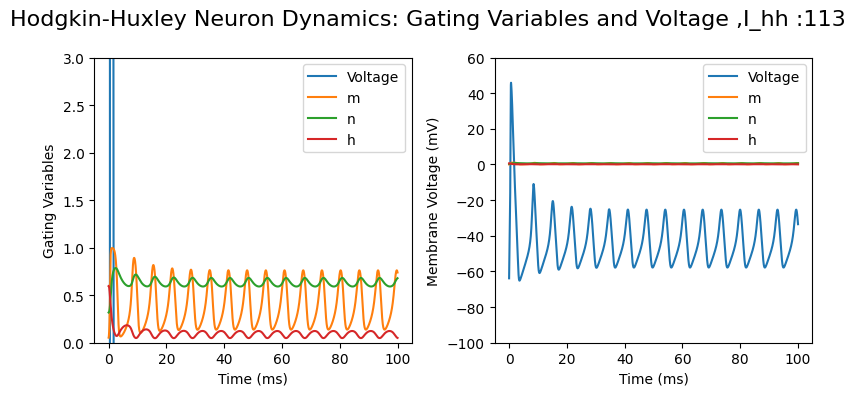

In [12]:
# Plot all variables, (everything except conductances) 

labels = ['Voltage', 'm', 'n', 'h']
state_vars = [v, m, n, h]

fig, axes = plt.subplots(1,2, figsize=(8, 4))
fig.suptitle(f'Hodgkin-Huxley Neuron Dynamics: Gating Variables and Voltage ,I_hh :{I_hh}', fontsize=16)



for i in range(len(state_vars)):
  axes[0].plot(time, state_vars[i], label= labels[i])
axes[0].legend(loc = 'upper right')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Gating Variables')
axes[0].set_ylim(0,3)

for i in range(len(state_vars)):
  axes[1].plot(time, state_vars[i], label=f'{labels[i]}') 
axes[1].legend(loc = 'upper right')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Membrane Voltage (mV)')
axes[1].set_ylim(-100, 60)

plt.tight_layout()

## Function to analyse voltage trace

In [13]:
def analyze_voltage_trace(v, t, T_total, I_app=None):
    """
    Counts APs, calculates firing rate, mean end voltage, and classifies HH firing regime.
    """
    peak_height = -20  # mV, captures all APs above -20 mV
    peaks, _ = signal.find_peaks(v, height=peak_height, distance=int(2 / (t[1]-t[0])))
    num_aps = len(peaks)
    firing_rate = num_aps / (T_total / 1000)  # T_total in ms, convert to seconds    
    v_end_mean = np.mean(v[int(0.8*len(v)):])
    block_threshold = -40  # mV

    # Classification using I_app threshold
    if I_app is not None and I_app >= 111:
        behavior = "Distorted/Blocked"
    elif num_aps == 0:
        behavior = "No APs"
    else:
        behavior = "Continuous Firing"

    return {
        'I_app': I_app,
        'num_aps': num_aps,
        'firing_rate': firing_rate,
        'v_end_mean': v_end_mean,
        'behavior': behavior
    }

### OG Function to Analyse Voltage trace Behaviour without Hardcoding
I faced a few challenges with this approach:
- It is hard to manually set a threshold for blocking and also action potential peak height. 
- Setting a manual threshold is 

In [14]:

# def analyze_voltage_trace_app1(v, t, T_total):
#     """
#     Improved: Counts APs and classifies HH firing regime.
#     """
#     # Use a dynamic threshold for peak detection
#     peak_height = -20  # mV, captures all APs above -20 mV
#     peaks, _ = signal.find_peaks(v, height=peak_height, distance=int(2 / (t[1]-t[0])))
#     num_aps = len(peaks)
#     firing_rate = num_aps / T_total if T_total > 0 else 0
#     v_end_mean = np.mean(v[int(0.8*len(v)):])
#     v_post_last_spike = np.mean(v[peaks[-1]:]) if num_aps > 0 else v_end_mean

#     block_threshold = -40  # mV, adjust as needed

#     if num_aps == 0:
#         behavior = "No APs"
#     elif v_end_mean > block_threshold or v_post_last_spike > block_threshold:
#         behavior = "Distorted/Blocked"
#     else:
#         # If last spike is far from end, not blocked, classify as finite APs
#         if peaks[-1] < int(0.8 * len(t)):
#             behavior = "Finite APs"
#         else:
#             behavior = "Continuous Firing"

#     return num_aps, firing_rate, behavior

## Simulate HH Model
- sweep I_app parameter from 0 to 160 uA 
- save the sweep results to a csv

In [15]:
# --- In your simulation loop ---
results = []
T_simulation = 500
I_apps = np.arange(0, 160, 1)
HH = HHModel(dt=0.01)

for i_app in tqdm(I_apps):
    v, m, n, h, g_na, g_k, time = HH.model(I_app=i_app, T=T_simulation)
    result = analyze_voltage_trace(v, time, T_simulation, I_app=i_app)
    results.append(result)

results_df = pd.DataFrame(results)

100%|██████████| 160/160 [02:09<00:00,  1.24it/s]


In [16]:
results_df.head()

,I_app,num_aps,firing_rate,v_end_mean,behavior
0,0,0,0.0,-64.996379,No APs
1,1,0,0.0,-64.193440,No APs
2,2,0,0.0,-63.482180,No APs
3,3,1,2.0,-62.843288,Continuous Firing
4,4,1,2.0,-62.262841,Continuous Firing


In [17]:
## save the dataframe to a csv file
pd.DataFrame.to_csv(results_df, 'hh_firing_behavior_I0_I160_sweep', index=False)

# Plot Firing rate vs. Applied current 
Also plot behaviour classification with I_app


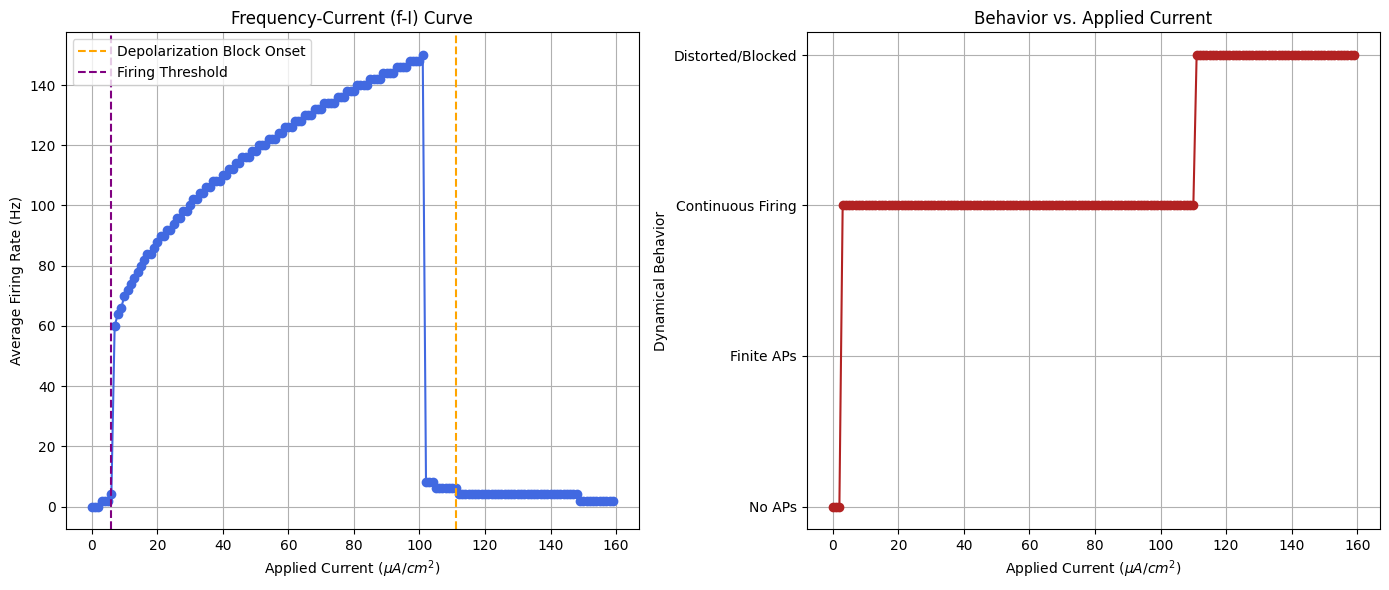

In [18]:
# Plot Firing Rate vs. Applied Current
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.title("Frequency-Current (f-I) Curve")
plt.plot(results_df['I_app'], results_df['firing_rate'], 'o-', color='royalblue')
plt.xlabel("Applied Current ($μA/cm^2$)")
plt.ylabel("Average Firing Rate (Hz)")
# plt.xlim(60, 70)
plt.axvline(x=111, color='orange', linestyle='--', label='Depolarization Block Onset')
plt.axvline(x=6, color='purple', linestyle='--', label='Firing Threshold')
plt.legend(loc = 'upper left')
plt.grid(True)


# Plot Dynamical Regions vs. Applied Current
plt.subplot(1, 2, 2)
behavior_categories = ["No APs", "Finite APs", "Continuous Firing", "Distorted/Blocked"]
# Assign a number to each category for plotting
y_codes = [behavior_categories.index(b) for b in results_df['behavior']]

plt.plot(results_df['I_app'], y_codes, 'o-', color='firebrick')
plt.yticks(ticks=range(len(behavior_categories)), labels=behavior_categories)
plt.xlabel("Applied Current ($μA/cm^2$)")
plt.ylabel("Dynamical Behavior")
plt.title("Behavior vs. Applied Current")
plt.grid(True)

plt.tight_layout()
plt.show()



## Plot all variables for Each Parameter Regime 
- I took a representative case for each regime 

In [19]:
def plot_detailed_dynamics(I_app, T=100):
    """
    Runs the HH model for a specific current and plots the detailed dynamics.
    """
    hh_sim = HHModel(dt=0.01)
    v, m, n, h, gNa, gK, time = hh_sim.model(I_app=I_app, T=T)
    
    fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    # 1. Plot Voltage Trace
    axs[0].plot(time, v, color='black')
    axs[0].set_title(f'Dynamics for I_app = {I_app} $μA/cm^2$')
    axs[0].set_ylabel('Voltage (mV)')
    axs[0].grid(True)
    
    # 2. Plot Gating Variables
    axs[1].plot(time, m, label='m (Na+ activation)')
    axs[1].plot(time, h, label='h (Na+ inactivation)')
    axs[1].plot(time, n, label='n (K+ activation)')
    axs[1].set_ylabel('Gating Variable')
    axs[1].legend()
    axs[1].grid(True)

    # 3. Plot Conductances
    axs[2].plot(time, gNa, label='$g_{Na}$', color='red')
    axs[2].plot(time, gK, label='$g_{K}$', color='blue')
    axs[2].set_ylabel('Conductance (mS/$cm^2$)')
    axs[2].set_xlabel('Time (ms)')
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()



In [25]:
# --- Now, plot the dynamics for one example current from each regime ---

# You'll need to find these values from your "Behavior vs. Applied Current" plot
I_no_ap = 3.0
I_finite_aps = 6.0  # This might show adaptation
I_continuous = 60.0
I_distorted = 140.0



### No action potential plots

--- Regime: No Action Potentials ---


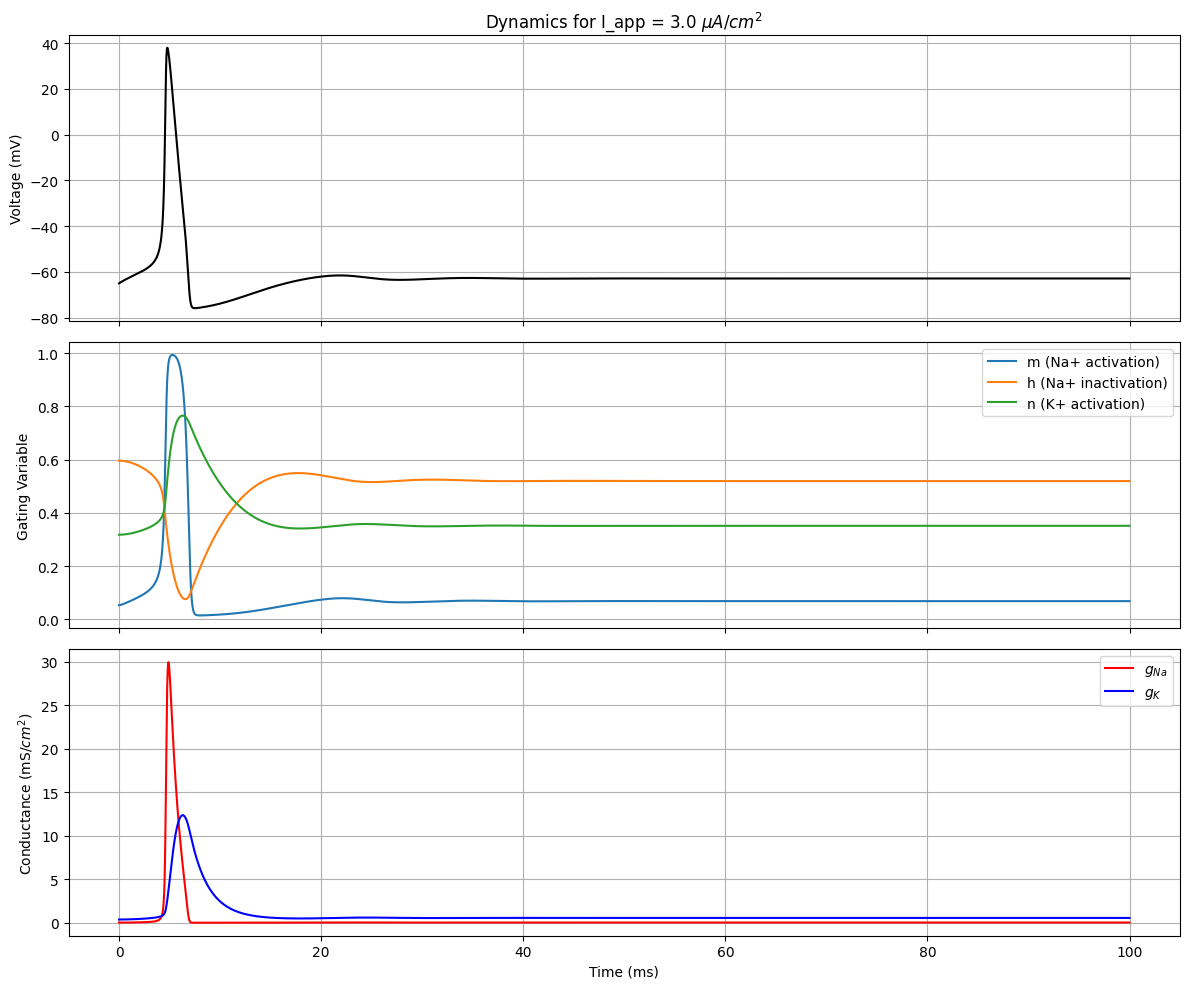

In [26]:
print("--- Regime: No Action Potentials ---")
plot_detailed_dynamics(I_no_ap)


### Finite Action Potential Plots


--- Regime: Finite Action Potentials ---


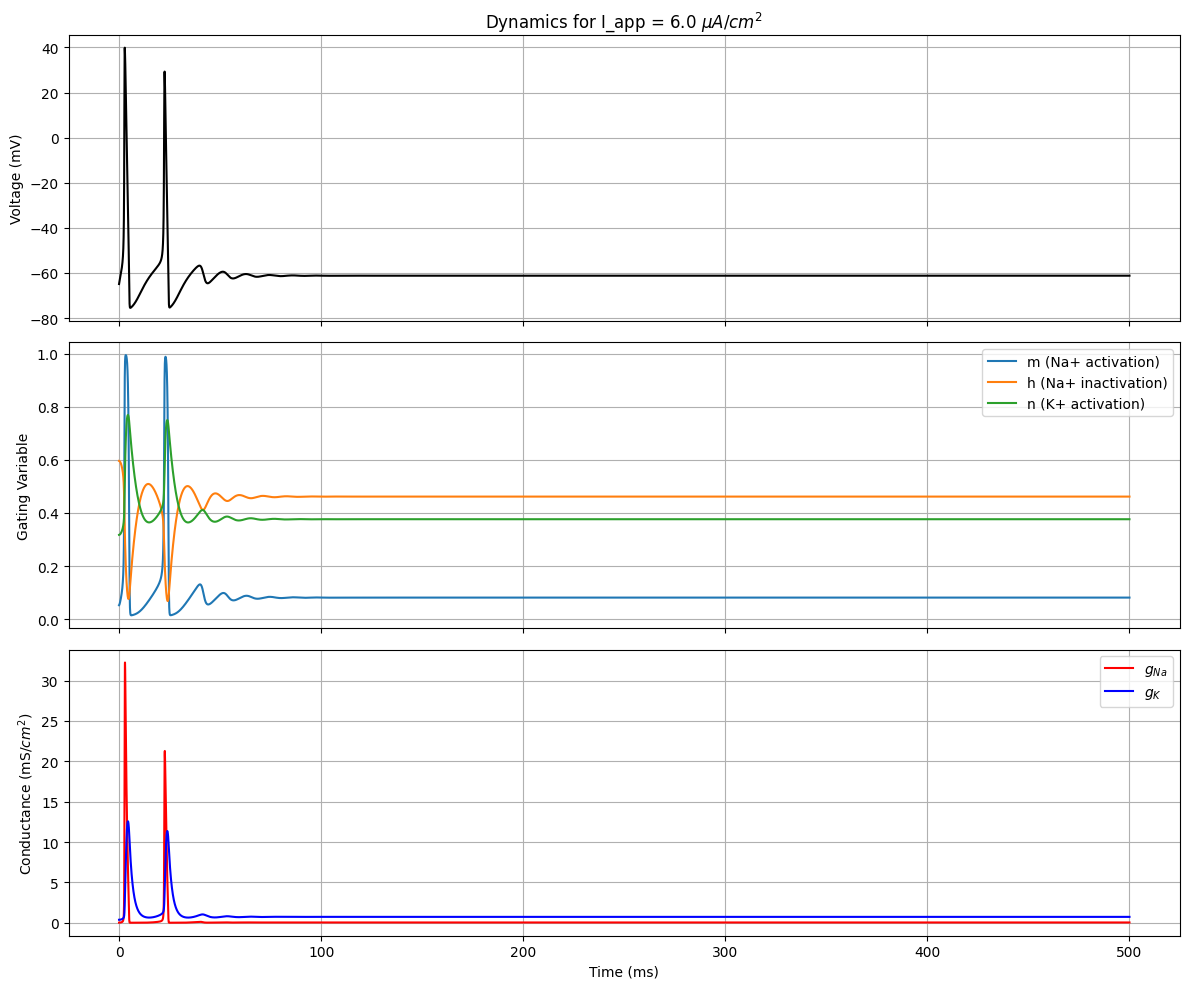

In [27]:

print("\n--- Regime: Finite Action Potentials ---")
plot_detailed_dynamics(I_finite_aps, T=500) # Longer time to see if it stops



### Plots for Continuos firing Regime


--- Regime: Continuous Firing ---


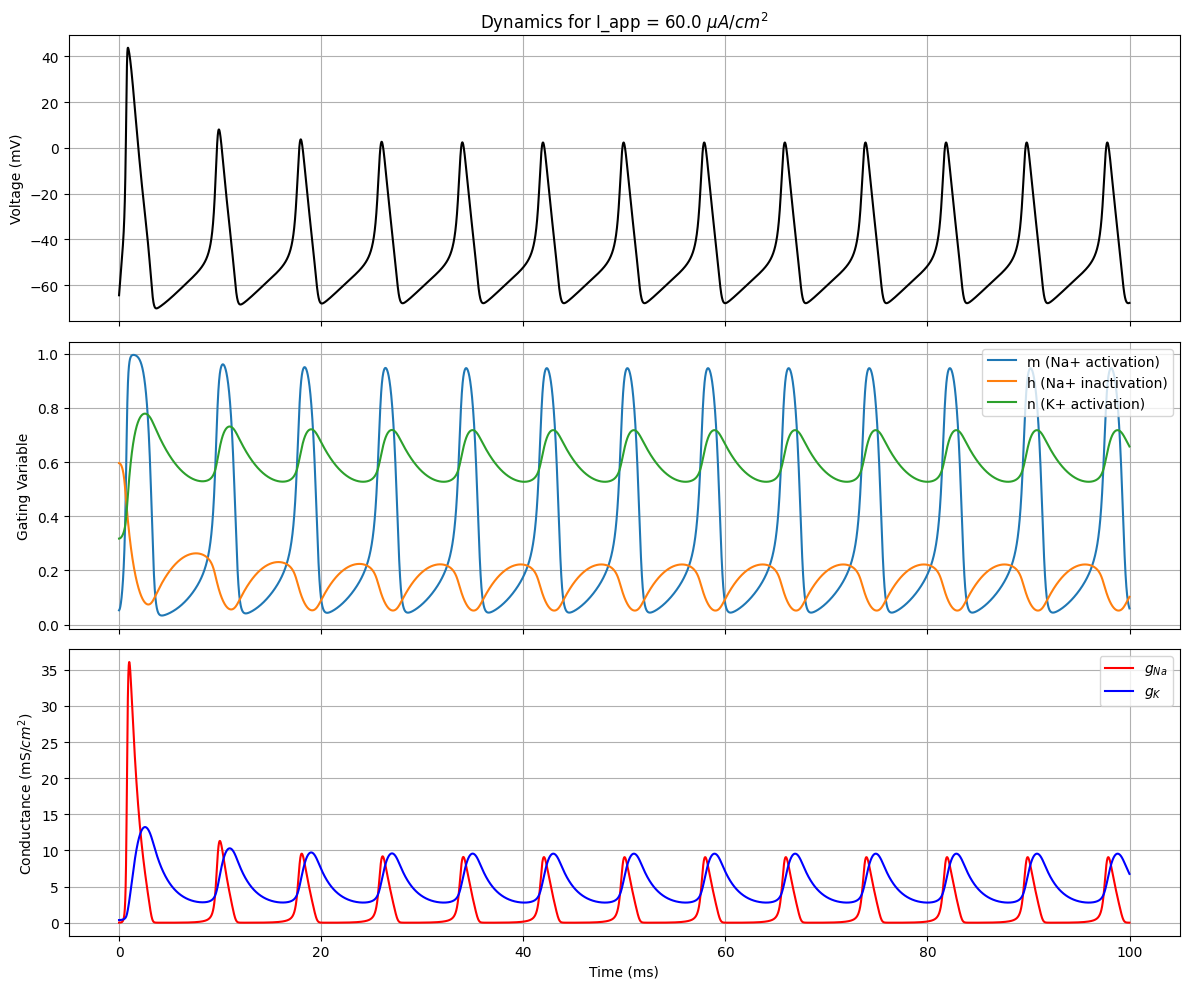

In [23]:
print("\n--- Regime: Continuous Firing ---")
plot_detailed_dynamics(I_continuous)


### Plots for Depolarisation Block 


--- Regime: Distorted / Depolarization Block ---


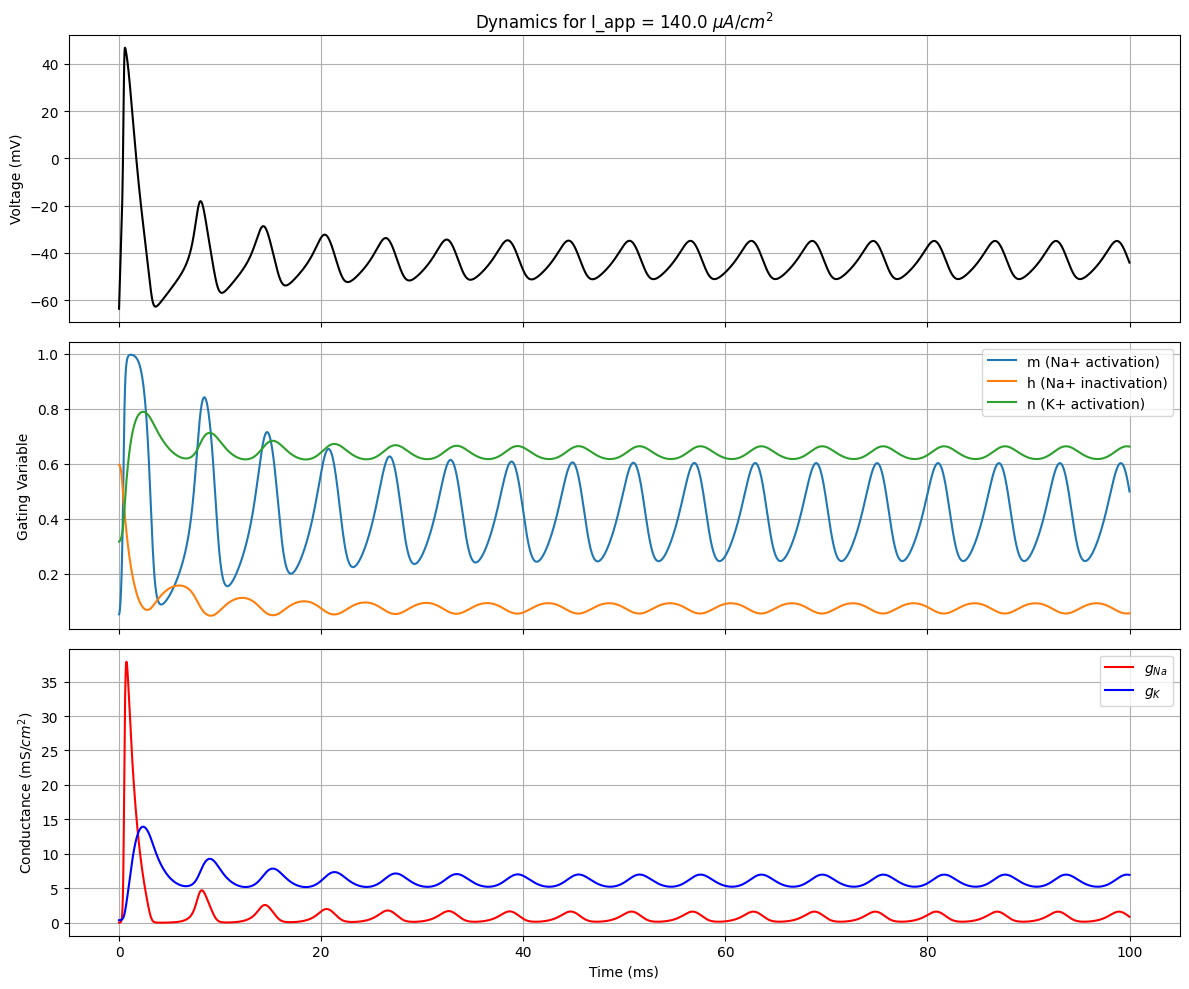

In [24]:

print("\n--- Regime: Distorted / Depolarization Block ---")
plot_detailed_dynamics(I_distorted)